## Задание 1

Применить ко всем растрам из папки «Изображения» фильтры высоких и низких частот. Сохранить обработанные изображения.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

image_dir = Path("Изображения")
result_dir = Path("results/practice1")
result_dir.mkdir(parents=True, exist_ok=True)

image_names = ["1.JPG", "2.jpg", "3.jpg", "4.jpg", "5.JPG"]


In [2]:
images = {}

for image_name in image_names:
    image_path = image_dir / image_name
    image = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_COLOR)
    images[image_name] = image
    h, w = image.shape[:2]
    print(f"{image_name}: {w} × {h}")


1.JPG: 1536 × 1024
2.jpg: 1600 × 1065
3.jpg: 2560 × 2097
4.jpg: 1240 × 785


5.JPG: 4960 × 3507


In [3]:
kernel_low = np.ones((5, 5), dtype=np.float32)
kernel_low = kernel_low / np.sum(kernel_low)

kernel_high = np.array([[0, -1, 0],
                        [-1, 4, -1],
                        [0, -1, 0]], dtype=np.float32)

kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]], dtype=np.float32)

print("Низкие частоты:")
print(kernel_low)
print("Высокие частоты:")
print(kernel_high)
print("Повышение резкости:")
print(kernel_sharp)


Низкие частоты:
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]
Высокие частоты:
[[ 0. -1.  0.]
 [-1.  4. -1.]
 [ 0. -1.  0.]]
Повышение резкости:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


In [4]:
images_low = {}
images_high = {}
images_sharp = {}

for image_name in image_names:
    image = images[image_name]

    image_low = cv2.filter2D(image, -1, kernel_low)
    image_high = cv2.filter2D(image, -1, kernel_high)
    image_sharp = cv2.filter2D(image, -1, kernel_sharp)

    images_low[image_name] = image_low
    images_high[image_name] = image_high
    images_sharp[image_name] = image_sharp

    image_num = image_name.split(".")[0]
    cv2.imwrite(str(result_dir / f"{image_num}_low.png"), image_low)
    cv2.imwrite(str(result_dir / f"{image_num}_high.png"), image_high)
    cv2.imwrite(str(result_dir / f"{image_num}_sharp.png"), image_sharp)

    print(f"{image_name}: сохранены low, high, sharp")


1.JPG: сохранены low, high, sharp


2.jpg: сохранены low, high, sharp


3.jpg: сохранены low, high, sharp
4.jpg: сохранены low, high, sharp


5.JPG: сохранены low, high, sharp


## Задание 2

Сравнить полученные изображения с исходными и составить описание (до-после). Указать, какие классы объектов стали наиболее ярко выражены. Сделать общий вывод о том, для каких целей лучше всего использовать фильтры высоких и низких частот.


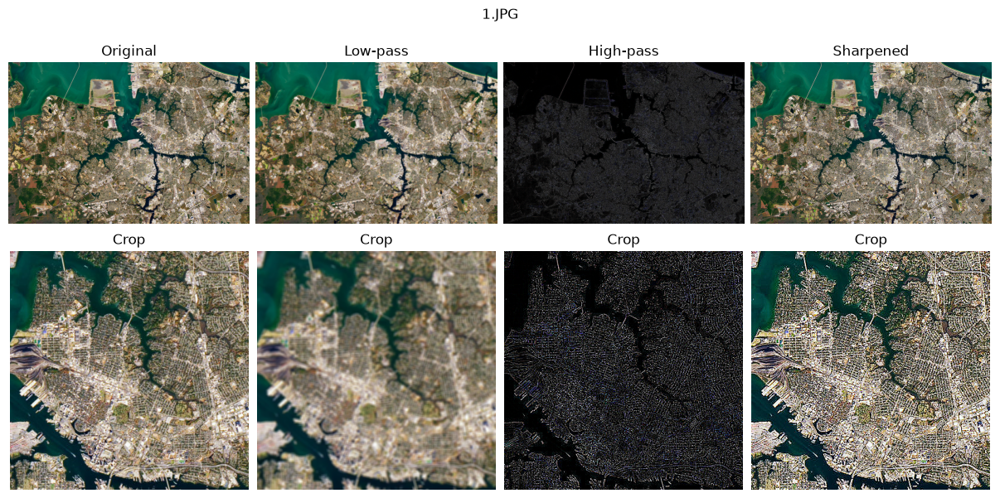

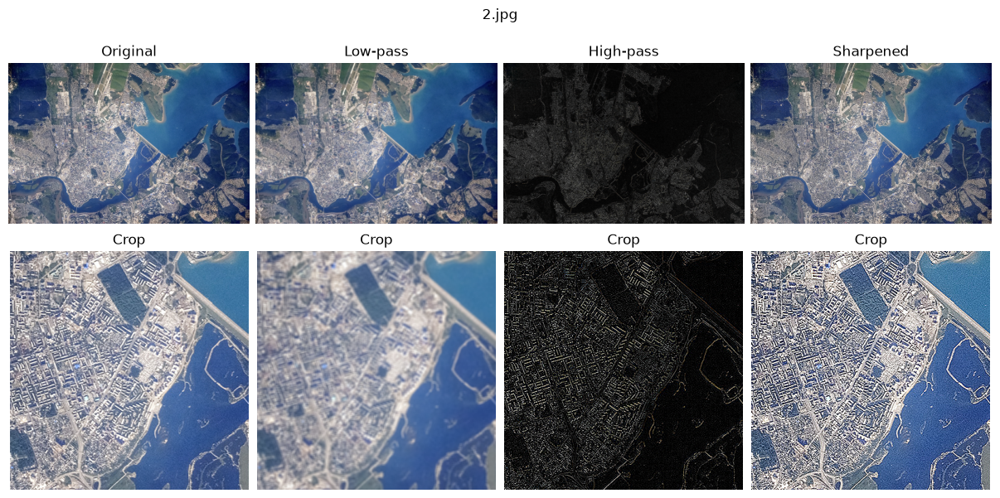

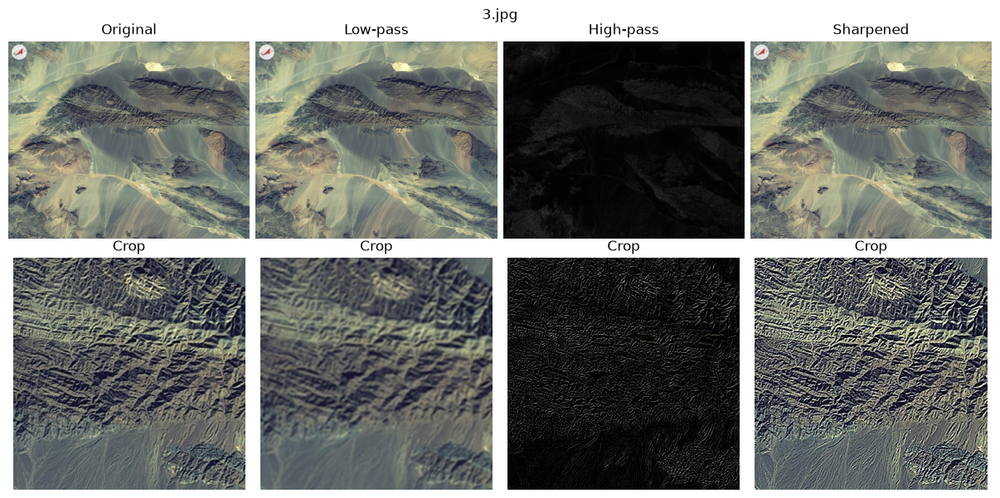

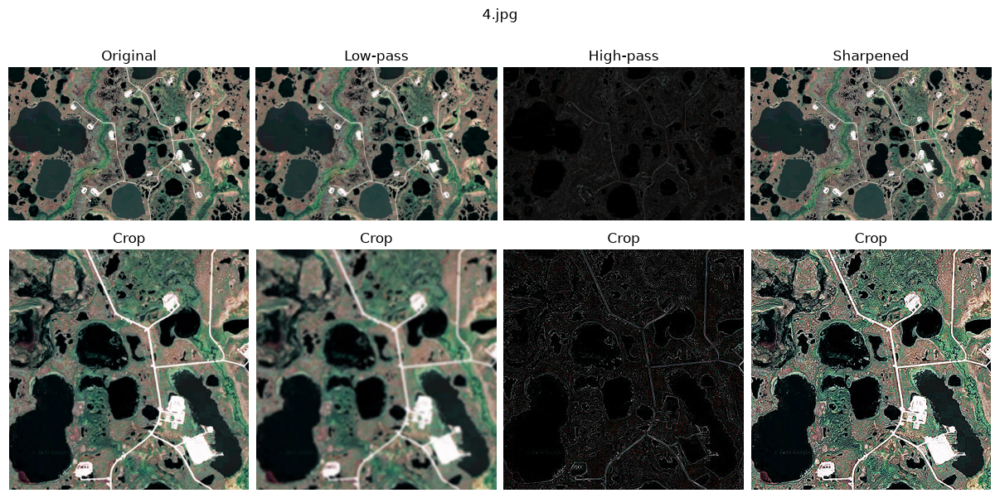

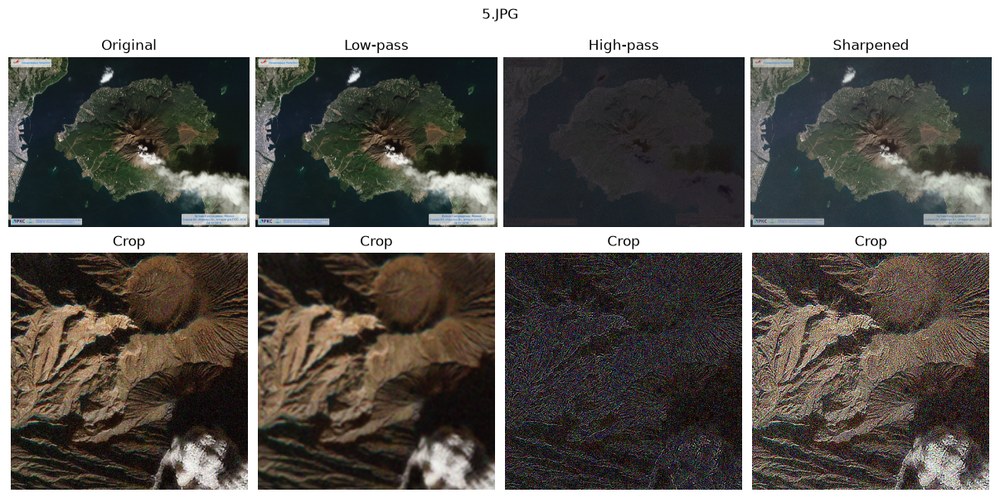

In [5]:
crop_params = [
    ("1.JPG", 800, 200),
    ("2.jpg", 550, 400),
    ("3.jpg", 850, 600),
    ("4.jpg", 600, 180),
    ("5.JPG", 2400, 1500)
]
titles = ["Original", "Low-pass", "High-pass", "Sharpened"]

for image_name, x, y in crop_params:
    compare_images = [images[image_name], images_low[image_name],
                      images_high[image_name], images_sharp[image_name]]

    plt.figure(figsize=(12, 6))
    plt.suptitle(image_name)

    for i in range(4):
        image_rgb = cv2.cvtColor(compare_images[i], cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i + 1)
        plt.title(titles[i])
        plt.imshow(image_rgb)
        plt.axis("off")

        plt.subplot(2, 4, i + 5)
        plt.title("Crop")
        plt.imshow(image_rgb[y:y+400, x:x+400])
        plt.axis("off")

    plt.tight_layout(pad=0.5)
    plt.show()


## Задание 3

Определить свои параметры ядра (задать матрицу со своими параметрами) и указать, для каких целей его можно использовать. Привести примеры. Изображения для обработки по своим параметрам можно выбирать любые, по желанию.


In [6]:
kernel_custom = np.array([[-1, 2, -1],
                          [-2, 4, -2],
                          [-1, 2, -1]], dtype=np.float32)
kernel_custom = kernel_custom / 4

print(kernel_custom)
print("Сумма коэффициентов:", np.sum(kernel_custom))


[[-0.25  0.5  -0.25]
 [-0.5   1.   -0.5 ]
 [-0.25  0.5  -0.25]]
Сумма коэффициентов: 0.0


In [7]:
images_custom = {}

for image_name in image_names:
    image = images[image_name]
    image_custom = cv2.filter2D(image, -1, kernel_custom)
    images_custom[image_name] = image_custom

    image_num = image_name.split(".")[0]
    cv2.imwrite(str(result_dir / f"{image_num}_custom.png"), image_custom)
    print(f"{image_name}: сохранён custom")


1.JPG: сохранён custom
2.jpg: сохранён custom


3.jpg: сохранён custom
4.jpg: сохранён custom


5.JPG: сохранён custom


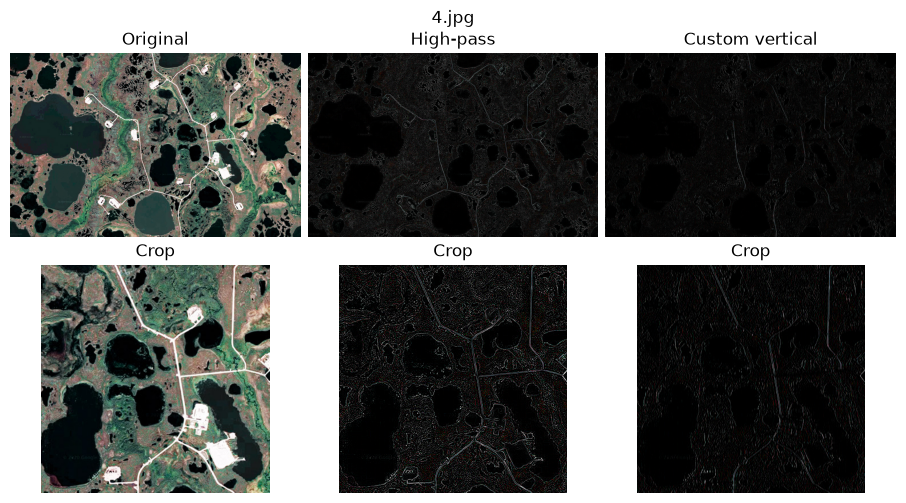

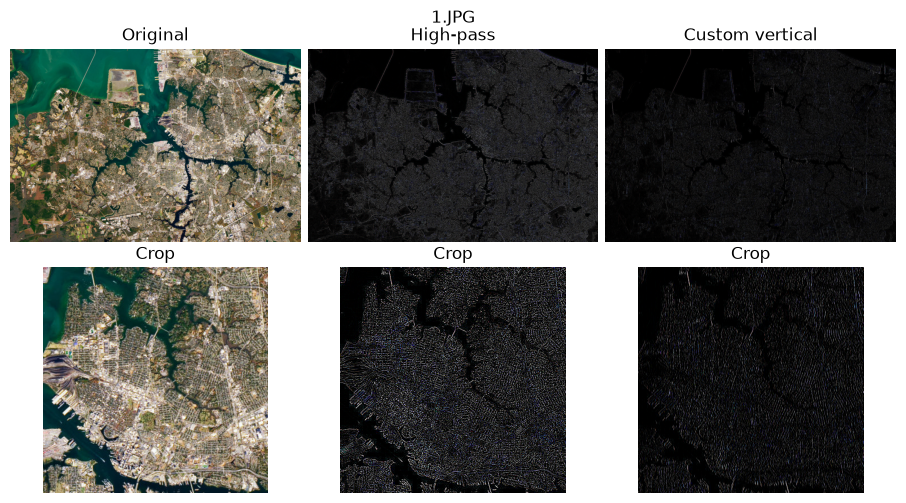

In [8]:
crop_params = [("4.jpg", 600, 180), ("1.JPG", 800, 200)]
titles = ["Original", "High-pass", "Custom vertical"]

for image_name, x, y in crop_params:
    compare_images = [images[image_name], images_high[image_name],
                      images_custom[image_name]]

    plt.figure(figsize=(9, 5))
    plt.suptitle(image_name)

    for i in range(3):
        image_rgb = cv2.cvtColor(compare_images[i], cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.title(titles[i])
        plt.imshow(image_rgb)
        plt.axis("off")

        plt.subplot(2, 3, i + 4)
        plt.title("Crop")
        plt.imshow(image_rgb[y:y+400, x:x+400])
        plt.axis("off")

    plt.tight_layout(pad=0.5)
    plt.show()
